In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)

In [120]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [121]:
df.shape

(891, 15)

In [122]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [124]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [125]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [126]:
df.duplicated().sum()

np.int64(107)

In [127]:
df.dtypes


,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object


In [128]:
df.nunique()

,0
survived,2
pclass,3
sex,2
age,88
sibsp,7
parch,7
fare,248
embarked,3
class,3
who,3


In [129]:
# Handle missing values

df["age"] = df["age"].fillna(df["age"].median())

df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

df["deck"] = df["deck"].fillna("Unknown")

In [130]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [131]:
df.isnull().sum().sum()

np.int64(0)

In [132]:
df = df.drop_duplicates()

In [133]:
df.duplicated().sum()

np.int64(0)

In [134]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object


In [135]:
df.shape

(781, 15)

In [136]:
df.isnull().sum().sum()

np.int64(0)

In [137]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000
mean,0.413572,2.240717,29.622817,0.524968,0.417414,34.750464
std,0.492789,0.855409,13.764671,0.987592,0.838132,52.237906
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,22.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,34.020800
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [138]:
df["survived"].value_counts()

,count
survived,
0,458
1,323


In [139]:
df["survived"].value_counts(normalize=True)*100

,proportion
survived,
0,58.642766
1,41.357234


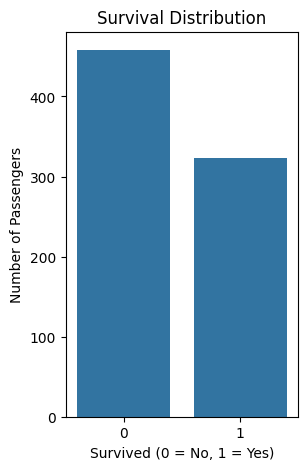

In [140]:
# Survival Distribution
plt.figure(figsize=(3,5))

sns.countplot(data=df, x="survived")

plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

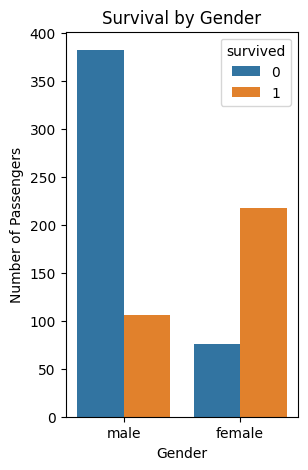

In [141]:
# Survival by Gender
plt.figure(figsize=(3,5))

sns.countplot(data=df, x="sex", hue="survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

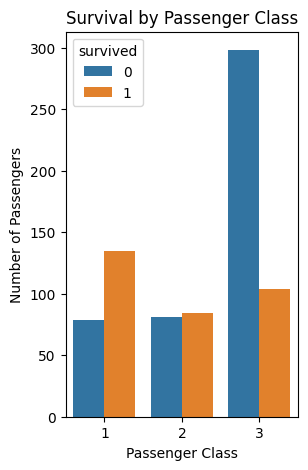

In [142]:
# Survival by Passenger Class
plt.figure(figsize=(3,5))

sns.countplot(data=df, x="pclass", hue="survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

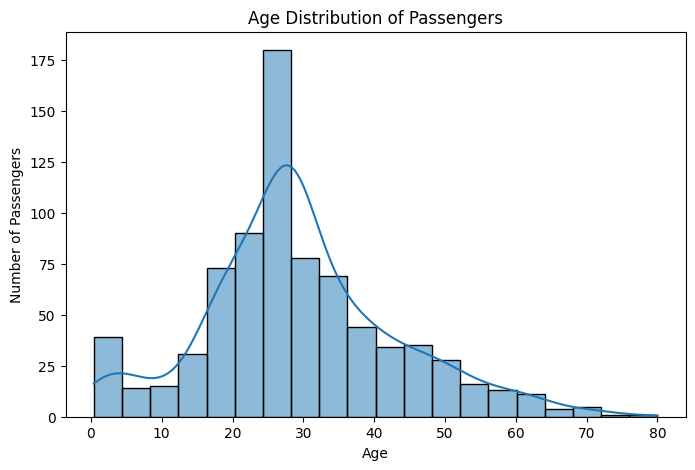

In [143]:
# Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="age", bins=20, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

In [144]:
correlation = df.select_dtypes(include="number").corr()
correlation

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.330755,-0.079430,-0.038368,0.068834,0.246585
pclass,-0.330755,1.000000,-0.343458,0.090002,0.042070,-0.549622
age,-0.079430,-0.343458,1.000000,-0.279579,-0.183348,0.091575
sibsp,-0.038368,0.090002,-0.279579,1.000000,0.380806,0.134884
parch,0.068834,0.042070,-0.183348,0.380806,1.000000,0.191747
fare,0.246585,-0.549622,0.091575,0.134884,0.191747,1.000000


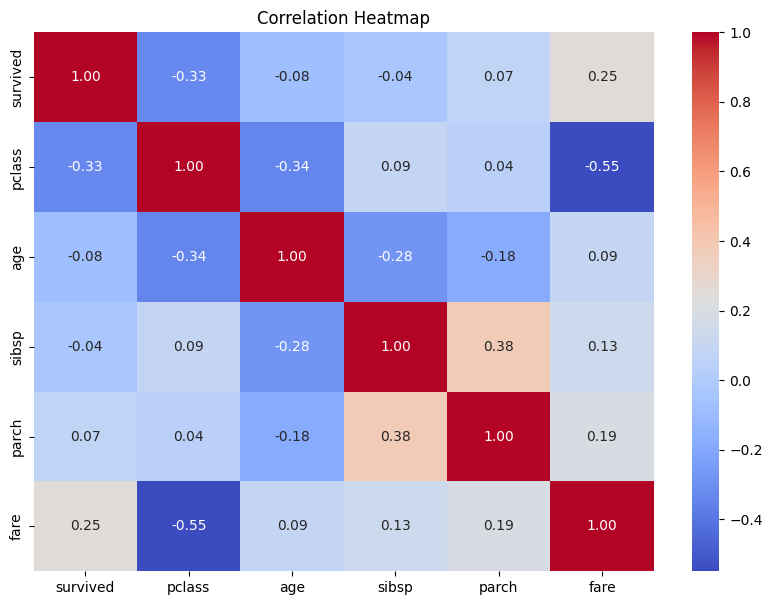

In [145]:
plt.figure(figsize=(10,7))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

In [146]:
survival_rate = df["survived"].mean() * 100
print(f"Overall Survival Rate: {survival_rate:.2f}%")

Overall Survival Rate: 41.36%


In [147]:
gender_survival = df.groupby("sex")["survived"].mean() * 100
print(gender_survival)

sex
female    74.061433
male      21.721311
Name: survived, dtype: float64


In [148]:
class_survival = df.groupby("pclass")["survived"].mean() * 100
print(class_survival)

pclass
1    63.084112
2    50.909091
3    25.870647
Name: survived, dtype: float64


In [149]:
print(f"Average Age: {df['age'].mean():.2f}")

Average Age: 29.62


In [150]:
print(f"Average Fare: {df['fare'].mean():.2f}")

Average Fare: 34.75


In [151]:
df.to_csv("titanic_cleaned.csv", index=False)

In [152]:
print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (781, 15)
Missing Values: 0
Duplicate Rows: 0
